# End-to-End ML Project · Week 3 Seminar
## Advanced Data Preparation: Feature Engineering & Preprocessing Pipeline

> **Dataset:** Used Car Prices (`car_prices_sample.csv`) — 10 000 rows, 12 features.  
> **Prerequisites:** You are already familiar with basic EDA (`.describe()`, `.info()`, simple histograms).  
> **Goal:** Practise *intermediate* data-preparation skills needed before training a regression model that predicts `sellingprice`.

---
### Webinar structure (~90 min)

| Block | Topic | Time |
|-------|-------|------|
| 0 | Setup & quick data sanity check | 5 min |
| 1 | Correlation & feature relationships | 15 min |
| 2 | Categorical feature cleaning | 15 min |
| 3 | Outlier detection & filtering | 15 min |
| 4 | Handling missing values | 15 min |
| 5 | Feature scaling | 10 min |
| 6 | Mini end-to-end pipeline challenge | 15 min |

---


## Block 0 · Setup & Sanity Check (5 min)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 20)
!curl -L "https://docs.google.com/uc?export=download&id=19TRiv2giWEpBpHL3fXrq__5-6VO_5WK7" -o ../data/sample_7.csv
df = pd.read_csv("../data/sample_7.csv")
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2013,Ford,Explorer,XLT,SUV,automatic,1fm5k7d80dgb98533,mi,25.0,42011.0,black,black,ford motor credit company llc,18000.0,Thu Mar 05 2015 01:00:00 GMT-0800 (PST)
1,2011,Ford,Ranger,XLT,SuperCab,automatic,1ftlr4fe9bpa61239,in,25.0,47930.0,white,gray,fiserv/citizens one auto finance,15000.0,Wed Jan 28 2015 16:00:00 GMT-0800 (PST)
2,2014,Subaru,Outback,2.5i Premium PZEV,Wagon,automatic,4s4brbcc1e3260991,nj,43.0,12495.0,blue,black,freehold dodge inc,22750.0,Wed Mar 04 2015 01:30:00 GMT-0800 (PST)
3,2014,FIAT,500L,Pop,Wagon,automatic,zfbcfaah5ez016657,ca,4.0,13427.0,white,black,hertz corporation/gdp,12000.0,Tue Dec 23 2014 12:30:00 GMT-0800 (PST)
4,2014,Toyota,Camry,LE,sedan,automatic,4t1bf1fk7eu826832,wi,35.0,14998.0,red,beige,toyota motor sales usa inc/program,15300.0,Wed Jun 03 2015 03:00:00 GMT-0700 (PDT)


> **🔎 Quick check — answer these before moving on:**
> 1. How many rows and columns does the dataset have?
> 2. Which columns are numerical? Which are categorical?
> 3. What is the target variable we want to predict?

In [17]:
print("Shape:", df.shape)
print()
print(df.info())
print()
print(df.describe())


Shape: (50000, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          50000 non-null  int64  
 1   make          49113 non-null  object 
 2   model         49101 non-null  object 
 3   trim          49085 non-null  object 
 4   body          48875 non-null  object 
 5   transmission  43959 non-null  object 
 6   vin           50000 non-null  object 
 7   state         50000 non-null  object 
 8   condition     48898 non-null  float64
 9   odometer      49995 non-null  float64
 10  color         49933 non-null  object 
 11  interior      49933 non-null  object 
 12  seller        50000 non-null  object 
 13  sellingprice  49998 non-null  float64
 14  saledate      49998 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 5.7+ MB
None

               year     condition       odometer   sellingprice
count  

>So, target variable would be **selling price**, and other parameters will only help us predict it.

---
## Block 1 · Correlation & Feature Relationships (15 min)

Before modelling we want to know *which numerical features are most relevant* to `sellingprice`.
A correlation heatmap is a fast first step, but it only captures **linear** relationships.


### Task 1.1 — Correlation heatmap
Compute and visualise the Pearson correlation matrix for all numerical columns.

**Requirements:**
- Use `sns.heatmap` with annotations and a diverging colour palette.
- Add a descriptive title.


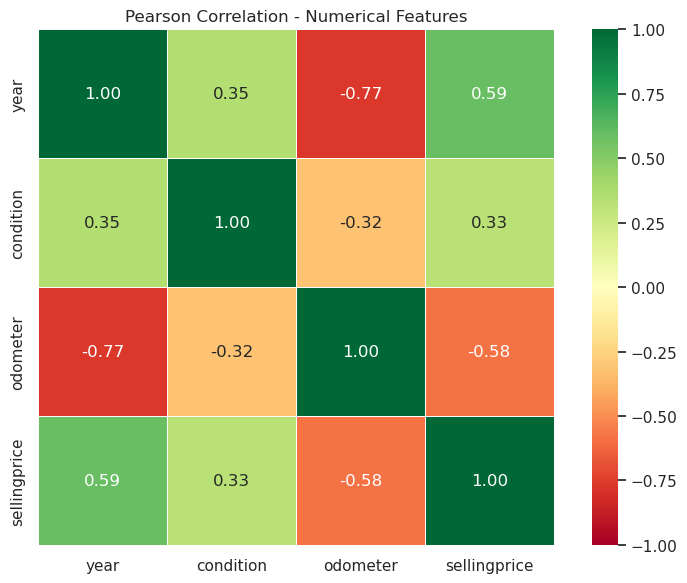

In [18]:
numerical_cols = ['year', 'condition', 'odometer', 'sellingprice']

corr = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, 
            square=True, linewidths=0.5)
plt.title('Pearson Correlation - Numerical Features')
plt.tight_layout()
plt.show()


**✏️ Interpretation questions:**
1. Which feature has the strongest positive correlation with `sellingprice`?
2. Which feature has the strongest negative correlation?
3. Is there any pair of *predictor* features that are highly correlated with each other (potential multicollinearity)?

*Write your answers as a markdown cell below.*


*Your interpretation here.*

### Task 1.2 — Scatter plots with regression line
Plot `sellingprice` against `odometer` and against `year` side-by-side.

**Requirements:**
- Use `sns.regplot` (adds a regression line automatically).
- Limit the y-axis to a reasonable range to avoid distortion from extreme outliers.
- Color the two plots differently.


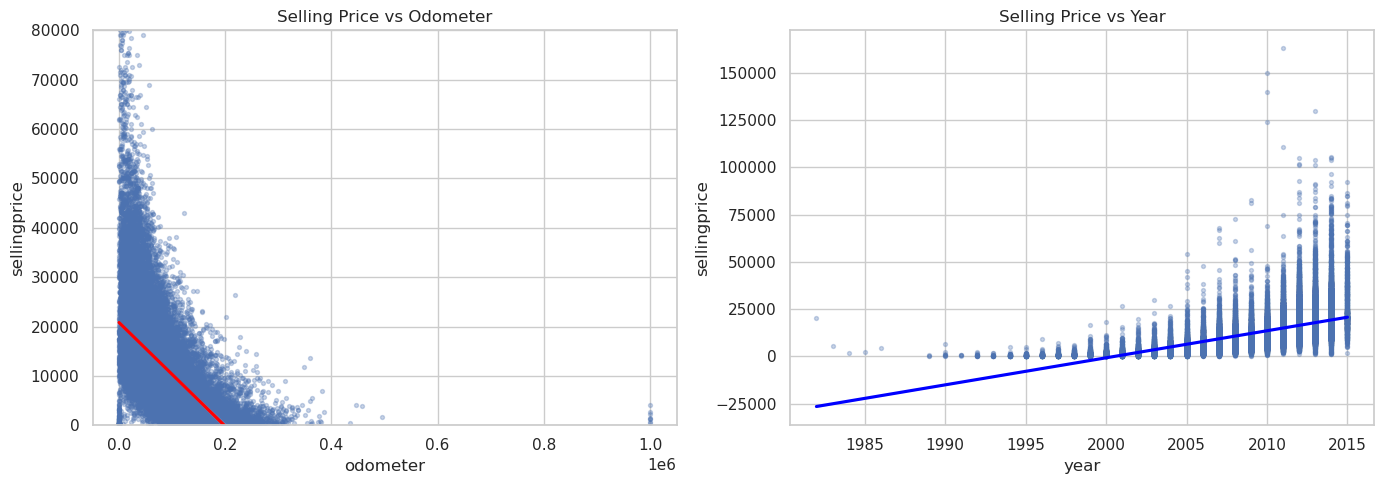

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='odometer', y='sellingprice', 
            scatter_kws={'alpha': 0.3, 's': 8}, 
            line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_ylim(0, 80000)
axes[0].set_title('Selling Price vs Odometer')

sns.regplot(data=df, x='year', y='sellingprice', 
            scatter_kws={'alpha': 0.3, 's': 8}, 
            line_kws={'color': 'blue'}, ax=axes[1])
axes[0].set_ylim(0, 80000)
axes[1].set_title('Selling Price vs Year')

plt.tight_layout()
plt.show()

### 🌟 Challenge 1.3 — Non-linear relationship check
The correlation matrix only captures linear relationships.  
Use a **box plot** to visualise `sellingprice` grouped by `year` (treat year as a category).  
Does the relationship look linear? What do you observe around 2008–2010?


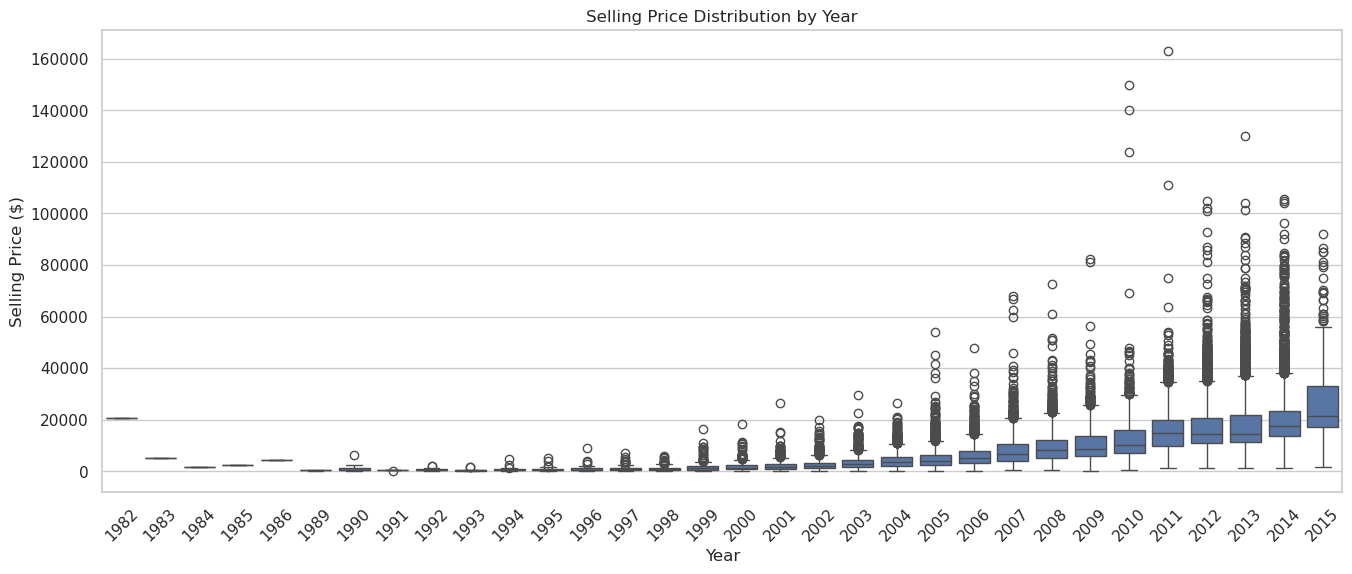

In [20]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='year', y='sellingprice')
plt.title('Selling Price Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Selling Price ($)')
plt.xlabel('Year')
plt.show()

---
## Block 2 · Categorical Feature Cleaning (15 min)

Real-world data is messy. Before encoding categorical columns we need to *standardise* them.


### Task 2.1 — Inspect categorical columns
Print the unique values and value counts for `make`, `body`, and `transmission`.  
Identify at least **one data-quality issue** in each column.


In [21]:
for col in ['make', 'body', 'transmission']:
    print(f"\n=== {col} — {df[col].nunique()} unique values ===")
    print(f"Unique values:", df[col].unique()[:20])  # First 20 unique values
    print("\nValue counts:")
    print(df[col].value_counts().head(15))
    print("-" * 50)


=== make — 79 unique values ===
Unique values: ['Ford' 'Subaru' 'FIAT' 'Toyota' 'Chevrolet' 'Dodge' 'Jeep' nan 'Hyundai'
 'Nissan' 'Cadillac' 'Mitsubishi' 'Infiniti' 'Chrysler' 'GMC'
 'Mercedes-Benz' 'Land Rover' 'Saturn' 'Ram' 'Kia']

Value counts:
make
Ford             8524
Chevrolet        5478
Nissan           4808
Toyota           3583
Dodge            2716
Honda            2402
Hyundai          1992
BMW              1875
Kia              1609
Chrysler         1534
Mercedes-Benz    1431
Jeep             1363
Infiniti         1335
Volkswagen       1128
Lexus            1102
Name: count, dtype: int64
--------------------------------------------------

=== body — 73 unique values ===
Unique values: ['SUV' 'SuperCab' 'Wagon' 'sedan' 'Sedan' 'suv' nan 'Crew Cab' 'hatchback'
 'supercrew' 'crew cab' 'Minivan' 'supercab' 'G Sedan' 'G Coupe'
 'Regular Cab' 'convertible' 'minivan' 'Convertible' 'Hatchback']

Value counts:
body
Sedan          17687
SUV            10786
sedan           3776


**✏️ Document the issues you found:**

| Column | Issue | Suggested fix |
|--------|-------|---------------|
| `make` | | |
| `body` | | |
| `transmission` | sedan | just errase |


### Task 2.2 — Clean `make` and `body`
Apply the following cleaning steps:

1. **`make`**: Standardise capitalisation (first letter upper, rest lower).
2. **`body`**: Standardise to *lowercase*. Then group rare body types (fewer than **50 occurrences**) into the category `"other"`.
3. **`transmission`**: Remove the single row where `transmission == 'Sedan'` (data entry error).

Work on a copy of the dataframe called `df_clean`.


In [22]:
df_clean = df.copy()

# Fix 'make' capitalisation
df_clean['make'] = df_clean['make'].apply(lambda x: str(x).capitalize())

# Fix 'body' — lowercase, then replace rare values with 'other'
df_clean['body'] = df_clean['body'].str.lower()
body_counts = df_clean['body'].value_counts()
rare_bodies = body_counts[body_counts < 50].index
df_clean['body'] = df_clean['body'].replace(rare_bodies, 'other')

# Remove the erroneous 'Sedan' row in 'transmission'
df_clean = df_clean[df_clean['transmission'] != 'Sedan']

print("Rows after cleaning:", len(df_clean))
print("Unique body types:", df_clean['body'].nunique())
print("\nBody type counts:")
print(df_clean['body'].value_counts())

Rows after cleaning: 50000
Unique body types: 19

Body type counts:
body
sedan           21463
suv             12971
minivan          2392
hatchback        2362
coupe            1570
crew cab         1503
wagon            1412
convertible       934
supercrew         863
g sedan           642
supercab          459
regular cab       431
van               411
extended cab      393
quad cab          363
other             262
e-series van      153
g coupe           149
double cab        142
Name: count, dtype: int64


### Task 2.3 — Visualise the cleaned distributions
Create a 1×2 figure showing:
- Left: count plot of `body` (sorted by frequency, horizontal bars preferred).
- Right: box plot of `sellingprice` grouped by `body`.

**Requirement:** The two plots must share the same ordering of body types.


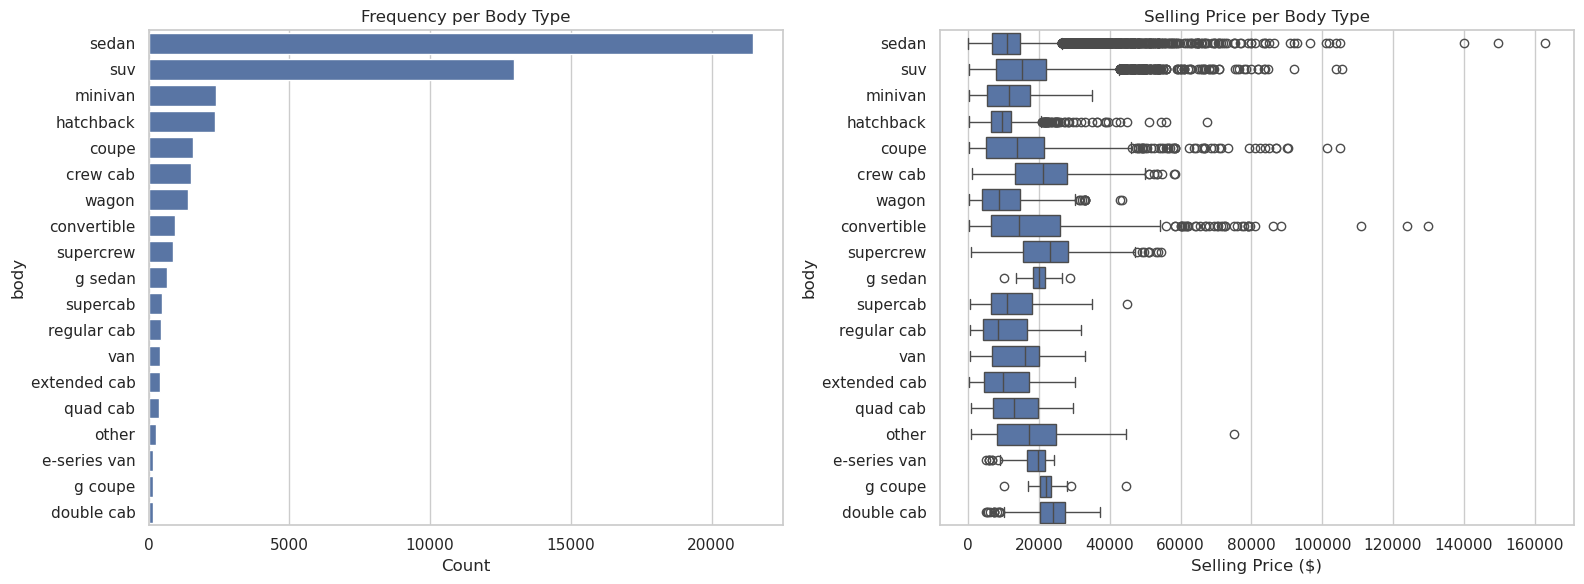

In [23]:
order = df_clean['body'].value_counts().index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_clean, y='body', order=order, ax=ax1)
ax1.set_title('Frequency per Body Type')
ax1.set_xlabel('Count')

sns.boxplot(data=df_clean, x='sellingprice', y='body', order=order, ax=ax2)
ax2.set_title('Selling Price per Body Type')
ax2.set_xlabel('Selling Price ($)')

plt.tight_layout()
plt.show()

### 🌟 Challenge 2.4 — Top makes analysis
From `df_clean`, keep only the **top 15 most frequent** car makes.  
Plot a horizontal bar chart showing the **median** `sellingprice` per make, sorted descending.  
Which brand has the highest median price? Does it surprise you?


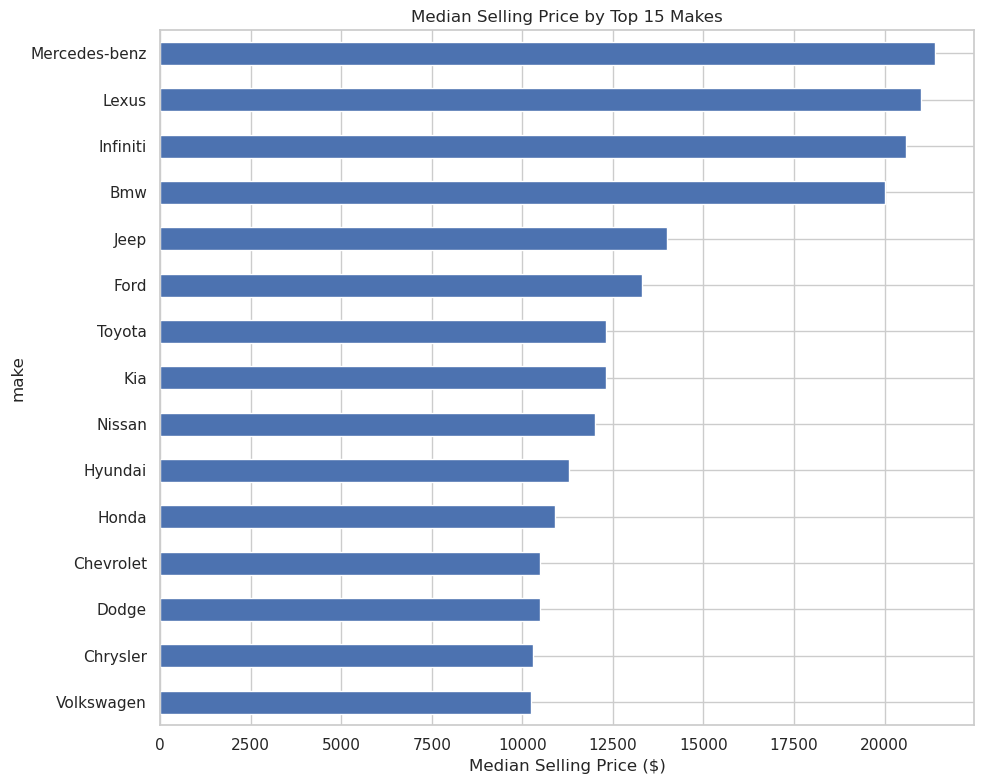

Top 5 makes by median price:
make
Jeep             14000.0
Bmw              20000.0
Infiniti         20600.0
Lexus            21000.0
Mercedes-benz    21400.0
Name: sellingprice, dtype: float64


In [24]:
top_makes = df_clean['make'].value_counts().head(15).index
df_top_makes = df_clean[df_clean['make'].isin(top_makes)]

make_median = df_top_makes.groupby('make')['sellingprice'].median().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
make_median.plot(kind='barh')
plt.title('Median Selling Price by Top 15 Makes')
plt.xlabel('Median Selling Price ($)')
plt.tight_layout()
plt.show()

print("Top 5 makes by median price:")
print(make_median.tail())

---
## Block 3 · Outlier Detection & Filtering (15 min)

Outliers in the target variable can distort model training.  
We will use **percentile-based filtering** and the **IQR method**.


### Task 3.1 — Visualise the price distribution
Plot the distribution of `sellingprice`:
1. Raw distribution (histogram + KDE).
2. Log-transformed distribution (`np.log(sellingprice)`).

Add vertical lines for the **10th, 25th, 50th, 75th, 90th, 95th, and 99th** percentiles on the raw plot.


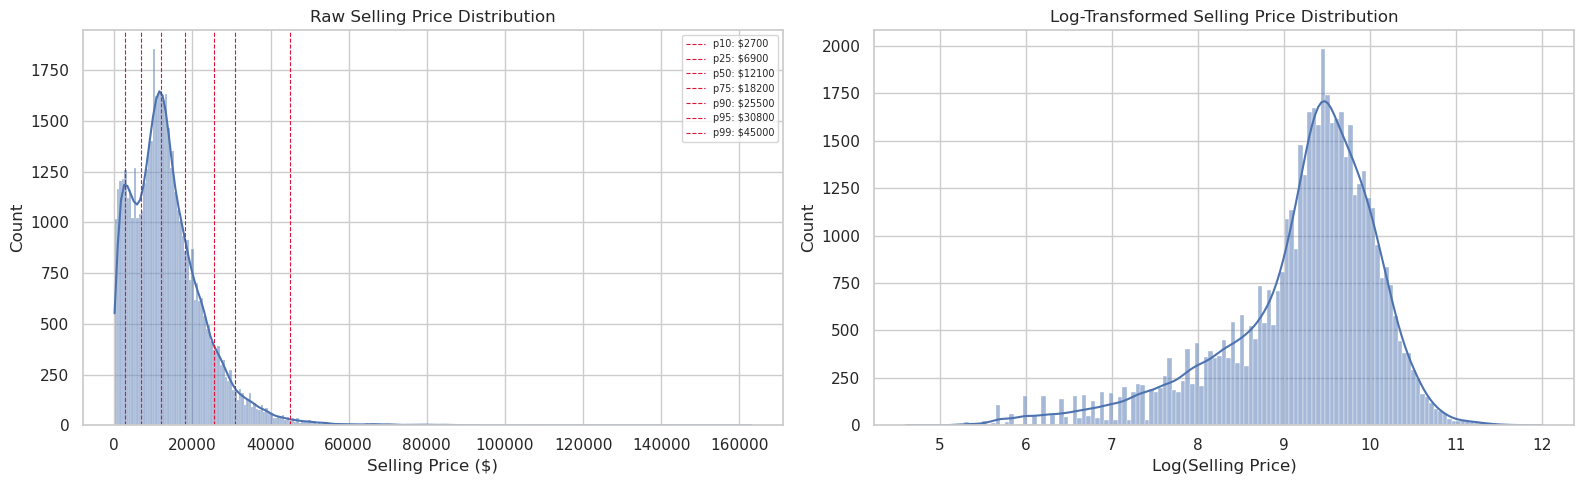

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

percentile_levels = [10, 25, 50, 75, 90, 95, 99]
percentiles = np.percentile(df_clean['sellingprice'].dropna(), percentile_levels)

sns.histplot(df_clean['sellingprice'], kde=True, ax=axes[0])
for level, val in zip(percentile_levels, percentiles):
    axes[0].axvline(val, color='crimson', lw=0.8, linestyle='--', 
                    label=f'p{level}: ${val:.0f}')
axes[0].legend(fontsize=7)
axes[0].set_title('Raw Selling Price Distribution')
axes[0].set_xlabel('Selling Price ($)')

sns.histplot(np.log(df_clean['sellingprice'].dropna()), kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Selling Price Distribution')
axes[1].set_xlabel('Log(Selling Price)')

plt.tight_layout()
plt.show()

### Task 3.2 — Percentile-based filtering
Remove rows where `sellingprice` is **above the 99th percentile**.  
Report:
- How many rows were removed?
- What was the 99th-percentile threshold?


In [26]:
p99 = np.percentile(df_clean['sellingprice'].dropna(), 99)
print(f"99th percentile threshold: ${p99:.0f}")

df_filtered = df_clean[df_clean['sellingprice'] <= p99].copy()
print(f"Rows removed: {len(df_clean) - len(df_filtered)}")
print(f"Remaining rows: {len(df_filtered)}")

99th percentile threshold: $45000
Rows removed: 491
Remaining rows: 49509


### Task 3.3 — IQR method for `odometer`
The IQR (Interquartile Range) method defines outliers as values beyond  
`Q1 − 1.5·IQR` or `Q3 + 1.5·IQR`.

1. Compute Q1, Q3, and IQR for `odometer`.
2. Print the lower and upper bounds.
3. Count how many rows fall outside these bounds.
4. **Decision:** should we drop them or cap them? Add a markdown cell explaining your reasoning.


In [27]:
Q1 = df_filtered['odometer'].quantile(0.25)
Q3 = df_filtered['odometer'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.0f}, Q3: {Q3:.0f}, IQR: {IQR:.0f}")
print(f"IQR bounds for odometer: [{lower:.0f}, {upper:.0f}]")

outlier_mask = (df_filtered['odometer'] < lower) | (df_filtered['odometer'] > upper)
print(f"Outlier rows: {outlier_mask.sum()}")
print(f"Percentage outliers: {(outlier_mask.sum()/len(df_filtered)*100):.1f}%")


Q1: 29073, Q3: 99569, IQR: 70496
IQR bounds for odometer: [-76671, 205314]
Outlier rows: 983
Percentage outliers: 2.0%


*Your decision and reasoning here.*

### 🌟 Challenge 3.4 — Combined outlier analysis
Create a **scatter plot** of `odometer` vs `sellingprice` (after your 99th-percentile filter).  
Colour points that fall outside the IQR bounds for `odometer` in red, others in blue.  
Does removing the odometer outliers look sensible given this plot?


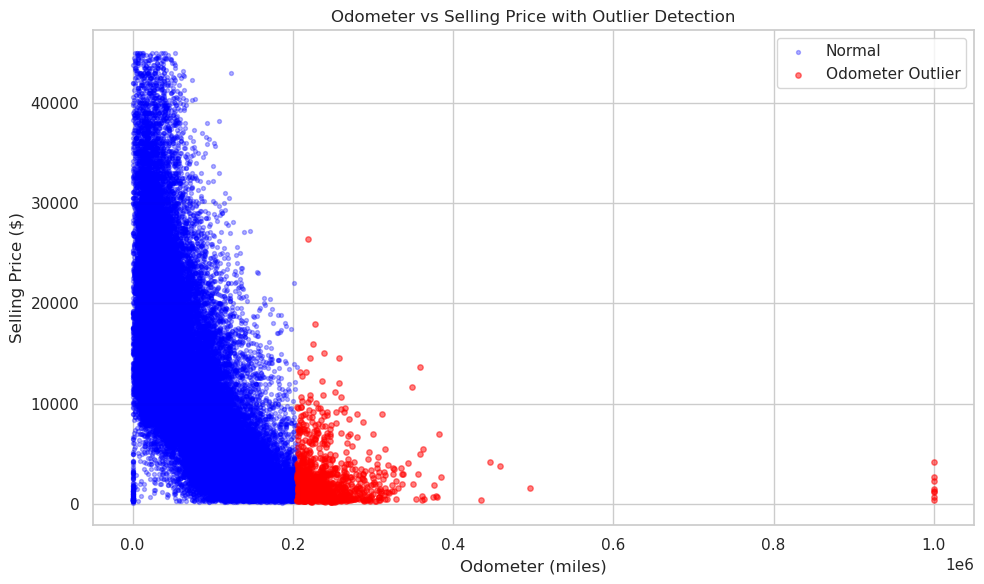

In [28]:
plt.figure(figsize=(10, 6))


plt.scatter(df_filtered.loc[~outlier_mask, 'odometer'], 
           df_filtered.loc[~outlier_mask, 'sellingprice'],
           alpha=0.3, s=8, color='blue', label='Normal')


plt.scatter(df_filtered.loc[outlier_mask, 'odometer'], 
           df_filtered.loc[outlier_mask, 'sellingprice'],
           alpha=0.5, s=15, color='red', label='Odometer Outlier')

plt.xlabel('Odometer (miles)')
plt.ylabel('Selling Price ($)')
plt.title('Odometer vs Selling Price with Outlier Detection')
plt.legend()
plt.tight_layout()
plt.show()


---
## Block 4 · Handling Missing Values (15 min)

`df_filtered` still has missing values. Let's deal with them systematically.


### Task 4.1 — Missing-value audit
Print the number and **percentage** of missing values per column in `df_filtered`.  
Visualise with a **horizontal bar chart** (percentage on x-axis).


              count    pct
transmission   5977  12.07
body           1113   2.25
condition      1102   2.23
trim            904   1.83
model           879   1.78
color            61   0.12
interior         61   0.12
odometer          5   0.01


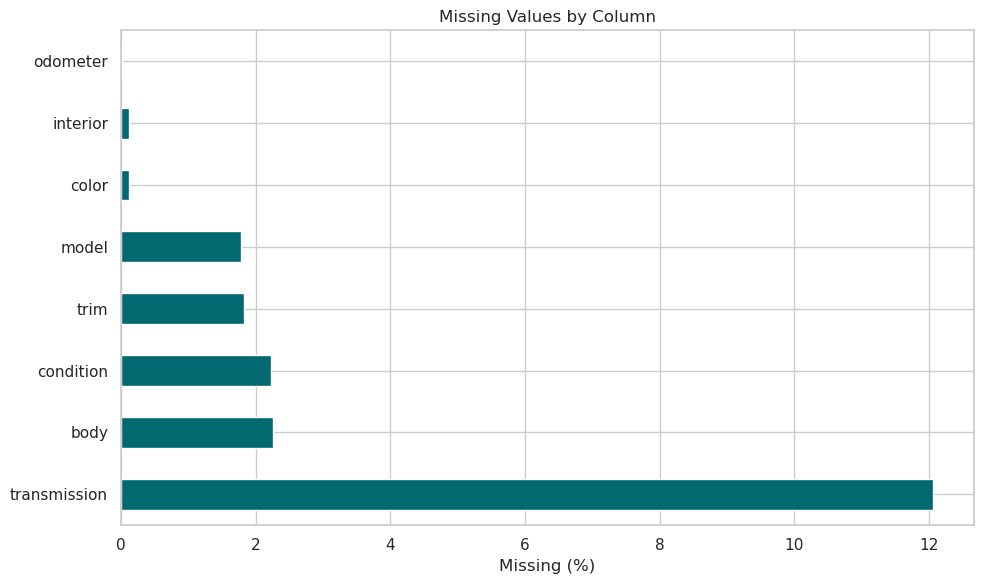

In [29]:
missing = df_filtered.isnull().sum()
missing_pct = (missing / len(df_filtered) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).query('count > 0').sort_values('pct', ascending=False)
print(missing_df)

if not missing_df.empty:
    plt.figure(figsize=(10, 6))
    missing_df['pct'].plot(kind='barh', color='#01696F')
    plt.xlabel('Missing (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

### Task 4.2 — Imputation strategy
Fill missing values using **different strategies** for different column types:

| Column(s) | Suggested strategy | Why |
|-----------|--------------------|-----|
| `condition`, `odometer` | median | Numerical — robust to remaining outliers |
| `transmission` | mode | Categorical — most frequent category |
| `make`, `model`, `trim`, `body`, `color`, `interior` | constant `"unknown"` | Categorical — preserve "missingness" signal |

Implement this using `SimpleImputer` from sklearn for the numerical columns,  
and `fillna` for the categorical ones.

After imputation, verify that there are **zero missing values** remaining.


In [30]:
from sklearn.impute import SimpleImputer

df_imputed = df_filtered.copy()

# Impute numerical columns with median
num_cols_to_impute = ['condition', 'odometer']
imp_med = SimpleImputer(strategy='median')
df_imputed[num_cols_to_impute] = imp_med.fit_transform(df_imputed[num_cols_to_impute])

# Impute transmission with mode
imp_mode = SimpleImputer(strategy='most_frequent')
df_imputed[['transmission']] = imp_mode.fit_transform(df_imputed[['transmission']])

# Fill categorical columns with 'unknown'
cat_cols_to_fill = ['make', 'model', 'trim', 'body', 'color', 'interior']
df_imputed[cat_cols_to_fill] = df_imputed[cat_cols_to_fill].fillna('unknown')

print("Missing values after imputation:")
print(df_imputed.isnull().sum())

Missing values after imputation:
year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
sellingprice    0
saledate        0
dtype: int64


### 🌟 Challenge 4.3 — Imputation impact check
Compare the distribution of `condition` **before and after** median imputation using overlapping histograms (use `alpha=0.5`).  
Did imputation significantly shift the distribution? What does this tell you?


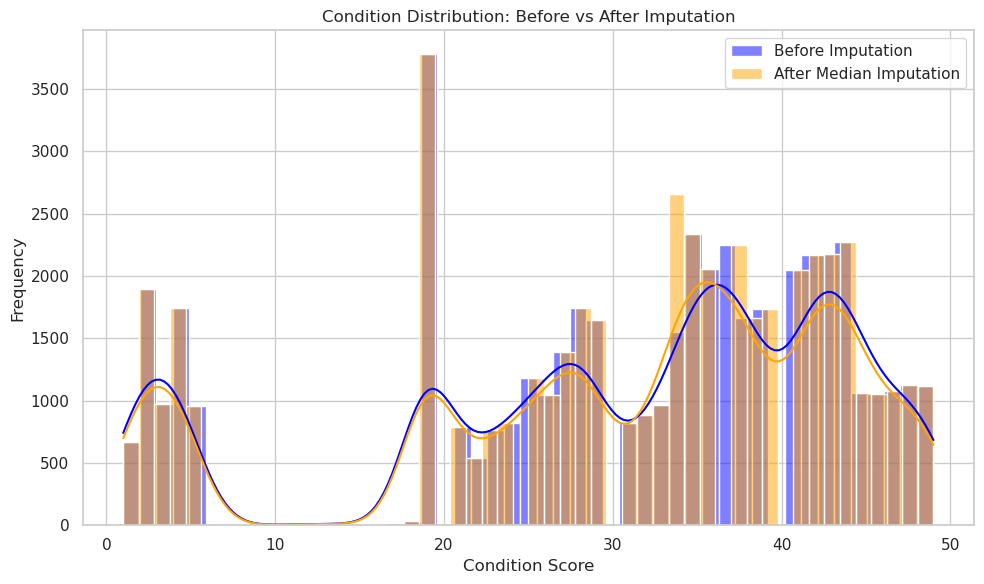

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

# Before imputation
sns.histplot(df_filtered['condition'].dropna(), alpha=0.5, label='Before Imputation', 
             color='blue', kde=True, ax=ax)

# After imputation
sns.histplot(df_imputed['condition'], alpha=0.5, label='After Median Imputation', 
             color='orange', kde=True, ax=ax)

plt.title('Condition Distribution: Before vs After Imputation')
plt.xlabel('Condition Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

---
## Block 5 · Feature Scaling (10 min)

Most ML models (linear regression, SVMs, neural networks) are sensitive to feature magnitude.  
We will compare **StandardScaler** and **MinMaxScaler**.


### Task 5.1 — Apply both scalers to `sellingprice`
1. Fit `StandardScaler` on `df_imputed['sellingprice']` and transform it.
2. Fit `MinMaxScaler` on the same column and transform it.
3. Plot three overlapping KDE curves (raw, standard-scaled, min-max-scaled) in one figure.


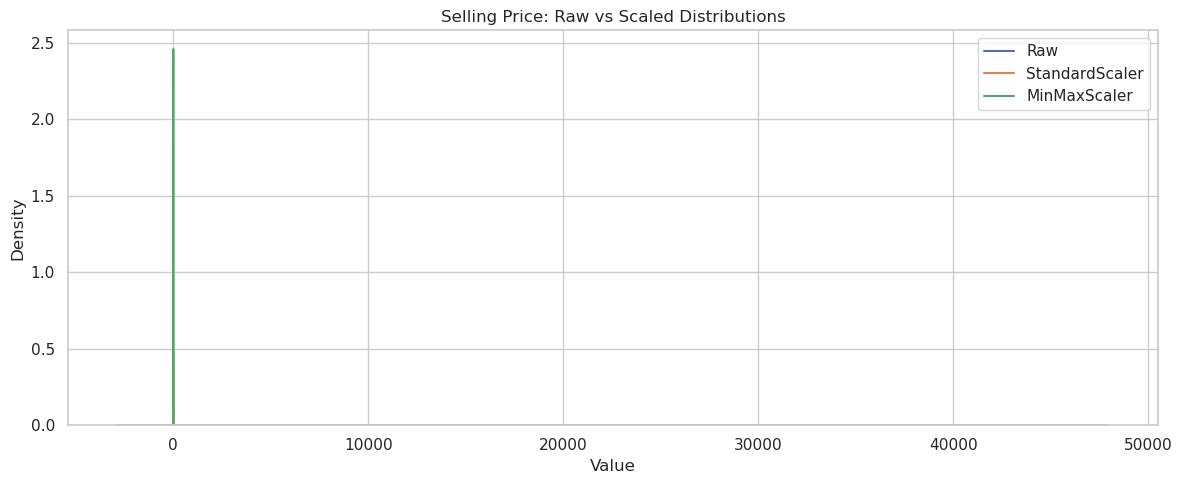

Std mean: 0.0000, std: 1.0000
MM min: 0.0000, max: 1.0000


In [32]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

prices = df_imputed[['sellingprice']].values

std_scaler = StandardScaler()
prices_std = std_scaler.fit_transform(prices)

mm_scaler = MinMaxScaler()
prices_mm = mm_scaler.fit_transform(prices)

fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(prices.flatten(), label='Raw', ax=ax)
sns.kdeplot(prices_std.flatten(), label='StandardScaler', ax=ax)
sns.kdeplot(prices_mm.flatten(), label='MinMaxScaler', ax=ax)

plt.title('Selling Price: Raw vs Scaled Distributions')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Std mean: {prices_std.mean():.4f}, std: {prices_std.std():.4f}')
print(f'MM min: {prices_mm.min():.4f}, max: {prices_mm.max():.4f}')

**✏️ Answer the following:**
1. What is the mean and standard deviation of the StandardScaler output?
2. What is the range [min, max] of the MinMaxScaler output?
3. Which scaler would you use for a model that is sensitive to outliers, and why?


*Your answers here.*

### Task 5.2 — Scale all numerical features
Apply `StandardScaler` to all numerical predictor columns: `year`, `condition`, `odometer`.  
Store the result back in `df_imputed` (rename the columns with a `_scaled` suffix).  
**Important:** fit the scaler *only* on the training data in a real pipeline — for now fit on the full dataset.


In [33]:
num_features = ['year', 'condition', 'odometer']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_imputed[num_features])

for i, col in enumerate(num_features):
    df_imputed[f'{col}_scaled'] = scaled_values[:, i]

df_imputed[['year_scaled', 'condition_scaled', 'odometer_scaled']].describe().round(3)

,year_scaled,condition_scaled,odometer_scaled
count,49509.000,49509.000,49509.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-7.007,-2.235,-1.283
25%,-0.752,-0.503,-0.742
50%,0.499,0.250,-0.299
75%,0.749,0.777,0.568
max,1.250,1.379,17.309


---
## Block 6 · Mini End-to-End Pipeline Challenge (15 min)

> This is the most important block — put together everything from Blocks 1–5 into a **reusable function**.

### Task 6.1 — Write a `preprocess` function
Implement the function below. It should accept a raw dataframe and return a clean, imputed, scaled dataframe ready for modelling.

Steps to include (in order):
1. Drop the single bad `transmission` row.
2. Standardise `make` (capitalize) and `body` (lowercase + group rare → "other", threshold 50).
3. Remove `sellingprice` above the 99th percentile.
4. Impute `condition` and `odometer` with median; `transmission` with mode; categorical columns with "unknown".
5. StandardScale `year`, `condition`, `odometer` (add `_scaled` suffix columns).
6. Return the cleaned dataframe.


In [51]:
def preprocess(raw_df: pd.DataFrame, rare_body_threshold: int = 50) -> pd.DataFrame:
    """
    Full preprocessing pipeline for the car prices dataset.
    """
    df = raw_df.copy()
    
    df = df[df['transmission'] != 'Sedan']
    
    df['make'] = df['make'].apply(lambda x: str(x).capitalize())
    df['body'] = df['body'].str.lower()
    body_counts = df['body'].value_counts()
    rare_bodies = body_counts[body_counts < rare_body_threshold].index
    df['body'] = df['body'].replace(rare_bodies, 'other')
    
    df = df.dropna(subset=['sellingprice'])
    
    p99 = np.percentile(df['sellingprice'], 99)
    
    df = df[df['sellingprice'] <= p99]
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols_to_impute = [col for col in numeric_cols if col != 'sellingprice']
    
    if numeric_cols_to_impute:
        imp_med = SimpleImputer(strategy='median')
        df[numeric_cols_to_impute] = imp_med.fit_transform(df[numeric_cols_to_impute])

    imp_mode = SimpleImputer(strategy='most_frequent')
    df[['transmission']] = imp_mode.fit_transform(df[['transmission']])
    
    obj_cols = df.select_dtypes(include=['object']).columns
    df[obj_cols] = df[obj_cols].fillna('unknown')
    
    df = df.fillna('unknown')
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    num_features_to_scale = ['year', 'condition', 'odometer']
    num_features_to_scale = [col for col in num_features_to_scale if col in df.columns]
    
    if num_features_to_scale:
        scaler = StandardScaler()
        scaled_values = scaler.fit_transform(df[num_features_to_scale])
        
        for i, col in enumerate(num_features_to_scale):
            df[f'{col}_scaled'] = scaled_values[:, i]
    
    return df


df_raw = pd.read_csv('data_sample.csv')
df_raw['sellingprice'] = df_raw['sellingprice'].fillna(df_raw['sellingprice'].median())
df_processed = preprocess(df_raw)

print("Max processed:", df_processed['sellingprice'].max())
print("p99 raw:", np.percentile(df_raw['sellingprice'], 99))

Max processed: 45000.0
p99 raw: 45000.0


### Task 6.2 — Sanity checks
Run the assertions below. All must pass with your `preprocess` function.


In [52]:
# Sanity checks — do NOT modify this cell
assert df_processed.isnull().sum().sum() == 0, "Still has missing values!"
assert 'Sedan' not in df_processed['transmission'].values, "Bad transmission row still present!"
assert df_processed['body'].str.islower().all(), "Body column not fully lowercase!"
assert df_processed['sellingprice'].max() <= np.percentile(df_raw['sellingprice'], 99) + 1, "Price outliers not removed!"
assert 'odometer_scaled' in df_processed.columns, "Scaled columns missing!"
assert round(df_processed['odometer_scaled'].mean(), 1) == 0.0, "Scaled mean should be ~0!"

print("✅ All checks passed!")


✅ All checks passed!


### 🌟 Final Challenge 6.3 — Feature importance preview
After preprocessing, encode `transmission` as a binary feature (0 = manual, 1 = automatic).  
Compute the **Pearson correlation** of every numerical column (including the new binary one) with `sellingprice`.  
Plot as a horizontal bar chart sorted by absolute correlation.  
Which feature turns out to be most linearly predictive of price?


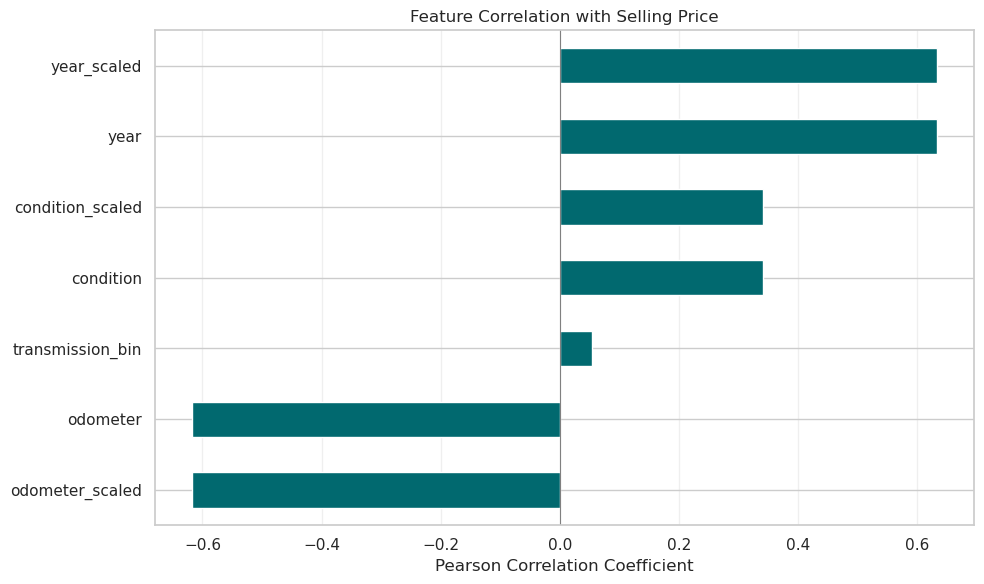

Feature correlations with selling price (sorted by absolute value):
year_scaled         0.632646
year                0.632646
odometer_scaled     0.617097
odometer            0.617097
condition_scaled    0.341577
condition           0.341577
transmission_bin    0.054309
Name: sellingprice, dtype: float64


In [53]:
df_processed['transmission_bin'] = (df_processed['transmission'] == 'automatic').astype(int)

num_cols = ['year', 'condition', 'odometer', 'transmission_bin', 
            'year_scaled', 'condition_scaled', 'odometer_scaled']

corr_with_target = df_processed[num_cols + ['sellingprice']].corr()['sellingprice'].drop('sellingprice').sort_values()

plt.figure(figsize=(10, 6))
corr_with_target.plot(kind='barh', color='#01696F')
plt.axvline(0, color='gray', lw=0.8)
plt.title('Feature Correlation with Selling Price')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Feature correlations with selling price (sorted by absolute value):")
print(corr_with_target.abs().sort_values(ascending=False))


---
## Homework (submit before next seminar)

1. **Encoding categorical features** — Apply one-hot encoding (`pd.get_dummies`) to `body` and `transmission` inside the `preprocess` function. Re-run the sanity checks.
2. **Interaction feature** — Create a new feature `age_x_odometer = (2025 - year) * odometer` and check whether it correlates more strongly with `sellingprice` than either `year` or `odometer` alone.
3. **Group-level imputation** — Instead of global median imputation for `condition`, impute missing values with the **median per `make`**. Compare the resulting distribution against the global-median approach from Block 4.
4. **Pipeline report** — Write a brief markdown summary (5–8 bullet points) describing every preprocessing decision you made and justifying it.


In [54]:
# STEP 1 - one-hot encoding

def preprocess_with_encoding(raw_df: pd.DataFrame, rare_body_threshold: int = 50) -> pd.DataFrame:
    """
    Full preprocessing pipeline with one-hot encoding.
    """
    df = raw_df.copy()
    
    df['sellingprice'] = df['sellingprice'].fillna(df['sellingprice'].median())
    
    df = df[df['transmission'] != 'Sedan']
    
    df['make'] = df['make'].apply(lambda x: str(x).capitalize())
    df['body'] = df['body'].str.lower()
    body_counts = df['body'].value_counts()
    rare_bodies = body_counts[body_counts < rare_body_threshold].index
    df['body'] = df['body'].replace(rare_bodies, 'other')
    
    df = df.dropna(subset=['sellingprice'])
    p99 = np.percentile(df['sellingprice'], 99)
    df = df[df['sellingprice'] <= p99]
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols_to_impute = [col for col in numeric_cols if col != 'sellingprice']
    
    if numeric_cols_to_impute:
        imp_med = SimpleImputer(strategy='median')
        df[numeric_cols_to_impute] = imp_med.fit_transform(df[numeric_cols_to_impute])

    imp_mode = SimpleImputer(strategy='most_frequent')
    df[['transmission']] = imp_mode.fit_transform(df[['transmission']])
    
    obj_cols = df.select_dtypes(include=['object']).columns
    df[obj_cols] = df[obj_cols].fillna('unknown')
    df = df.fillna('unknown')
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    num_features_to_scale = ['year', 'condition', 'odometer']
    num_features_to_scale = [col for col in num_features_to_scale if col in df.columns]
    
    if num_features_to_scale:
        scaler = StandardScaler()
        scaled_values = scaler.fit_transform(df[num_features_to_scale])
        
        for i, col in enumerate(num_features_to_scale):
            df[f'{col}_scaled'] = scaled_values[:, i]
    
    df = pd.get_dummies(df, columns=['body', 'transmission'], drop_first=True)
    
    return df

In [55]:
df_raw = pd.read_csv('data_sample.csv')
df_raw['sellingprice'] = df_raw['sellingprice'].fillna(df_raw['sellingprice'].median())
df_processed_encoded = preprocess_with_encoding(df_raw)

In [57]:
#Sanity check
print("Shape:", df_processed_encoded.shape)
print("Missing values:", df_processed_encoded.isnull().sum().sum())
assert df_processed_encoded.isnull().sum().sum() == 0, "Still has missing values!"
assert 'Sedan' not in df_raw['transmission'].values, "Bad transmission row still present!"  # Check in df_raw
assert df_processed_encoded['sellingprice'].max() <= np.percentile(df_raw['sellingprice'], 99) + 1, "Price outliers not removed!"
assert 'odometer_scaled' in df_processed_encoded.columns, "Scaled columns missing!"
assert round(df_processed_encoded['odometer_scaled'].mean(), 1) == 0.0, "Scaled mean should be ~0!"

print("✅ All checks passed")

Shape: (49511, 37)
Missing values: 0
✅ All checks passed


In [58]:
print("New columns after one-hot encoding:")
new_cols = [col for col in df_processed_encoded.columns if col.startswith('body_') or col.startswith('transmission_')]
print(new_cols)

New columns after one-hot encoding:
['body_coupe', 'body_crew cab', 'body_double cab', 'body_e-series van', 'body_extended cab', 'body_g coupe', 'body_g sedan', 'body_hatchback', 'body_minivan', 'body_other', 'body_quad cab', 'body_regular cab', 'body_sedan', 'body_supercab', 'body_supercrew', 'body_suv', 'body_unknown', 'body_van', 'body_wagon', 'transmission_manual', 'transmission_sedan']


In [59]:
#STEP 2 - interation feature implementation

df_processed['age'] = 2025 - df_processed['year']
df_processed['age_x_odometer'] = df_processed['age'] * df_processed['odometer']

In [60]:
correlations = {
    'year': df_processed['year'].corr(df_processed['sellingprice']),
    'odometer': df_processed['odometer'].corr(df_processed['sellingprice']),
    'age_x_odometer': df_processed['age_x_odometer'].corr(df_processed['sellingprice']),
    'age': df_processed['age'].corr(df_processed['sellingprice'])
}

print("Correlation with selling price:")
for feature, corr in correlations.items():
    print(f"  {feature:20s}: {corr:+.4f}")

Correlation with selling price:
  year                : +0.6326
  odometer            : -0.6171
  age_x_odometer      : -0.6184
  age                 : -0.6326



Strongest correlation: year (r = +0.6326)


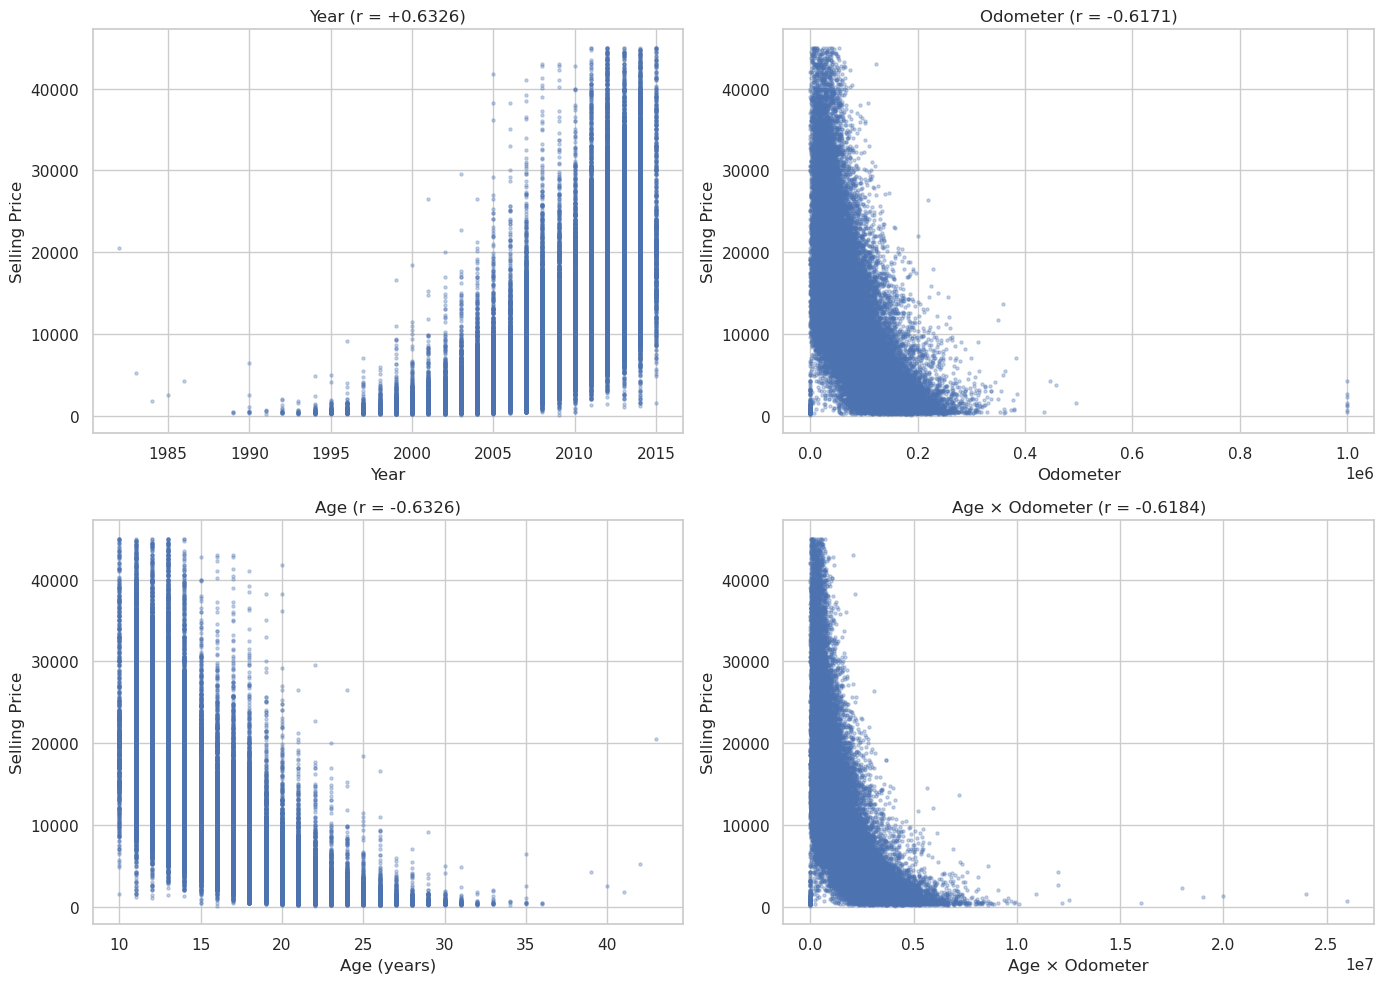

In [62]:
#Let's plot it all so it will be seen more clearly

strongest = max(correlations.items(), key=lambda x: abs(x[1]))
print(f"\nStrongest correlation: {strongest[0]} (r = {strongest[1]:+.4f})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Year vs Price
axes[0, 0].scatter(df_processed['year'], df_processed['sellingprice'], alpha=0.3, s=5)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Selling Price')
axes[0, 0].set_title(f'Year (r = {correlations["year"]:+.4f})')

#Odometer vs Price
axes[0, 1].scatter(df_processed['odometer'], df_processed['sellingprice'], alpha=0.3, s=5)
axes[0, 1].set_xlabel('Odometer')
axes[0, 1].set_ylabel('Selling Price')
axes[0, 1].set_title(f'Odometer (r = {correlations["odometer"]:+.4f})')

#Age vs Price
axes[1, 0].scatter(df_processed['age'], df_processed['sellingprice'], alpha=0.3, s=5)
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Selling Price')
axes[1, 0].set_title(f'Age (r = {correlations["age"]:+.4f})')

#Age × Odometer vs Price
axes[1, 1].scatter(df_processed['age_x_odometer'], df_processed['sellingprice'], alpha=0.3, s=5)
axes[1, 1].set_xlabel('Age × Odometer')
axes[1, 1].set_ylabel('Selling Price')
axes[1, 1].set_title(f'Age × Odometer (r = {correlations["age_x_odometer"]:+.4f})')

plt.tight_layout()
plt.show()

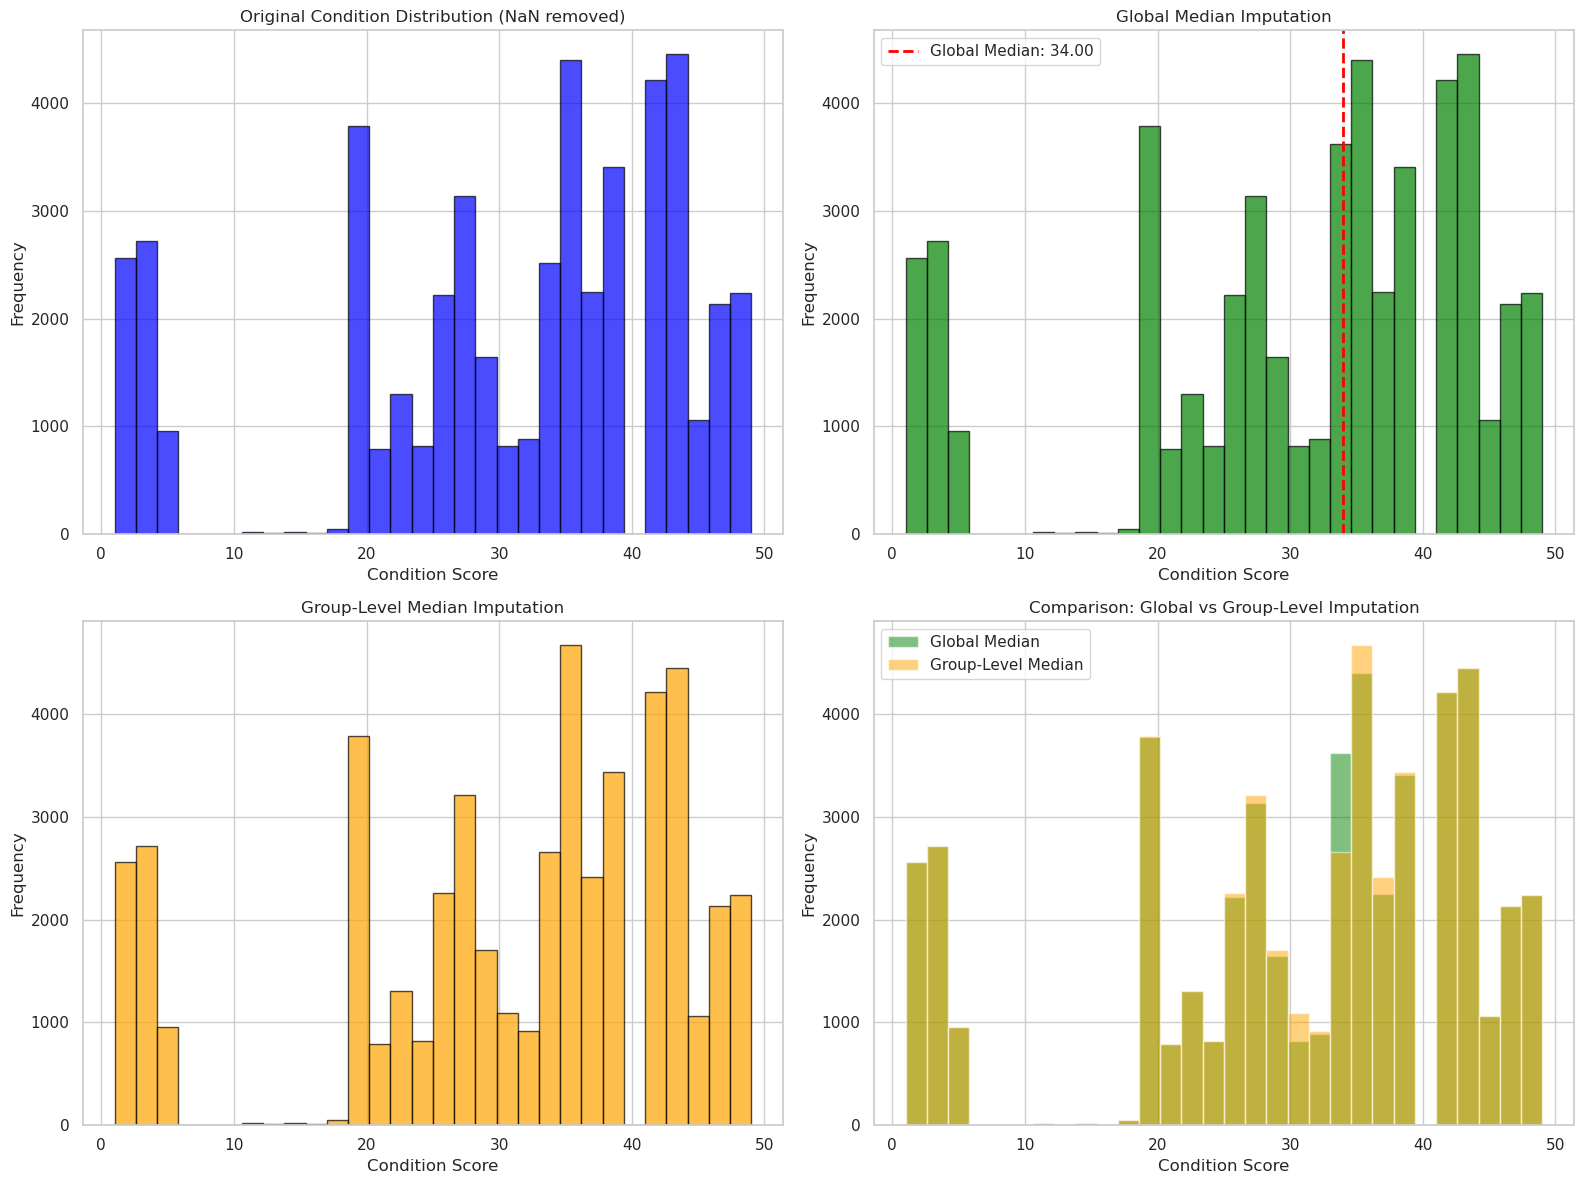

Statistical Comparison:

Global Median Imputation:
  Mean:   30.679
  Std:    13.282
  Median: 34.000

Group-Level Median Imputation:
  Mean:   30.657
  Std:    13.288
  Median: 34.000

Original:
  Mean:   30.603
  Std:    13.423
  Median: 34.000


In [64]:
#STEP 3 - group-level computation

df_group_imputed = df_filtered.copy()

global_median = df_filtered['condition'].median()
df_group_imputed['condition_group_median'] = df_group_imputed.groupby('make')['condition'].transform('median')

df_group_imputed['condition_group_imputed'] = df_group_imputed['condition'].fillna(df_group_imputed['condition_group_median'])
df_group_imputed['condition_global_imputed'] = df_group_imputed['condition'].fillna(global_median)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Original distributio
axes[0, 0].hist(df_group_imputed['condition'].dropna(), bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Original Condition Distribution (NaN removed)')
axes[0, 0].set_xlabel('Condition Score')
axes[0, 0].set_ylabel('Frequency')

#Global median imputation
axes[0, 1].hist(df_group_imputed['condition_global_imputed'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(global_median, color='red', linestyle='--', linewidth=2, label=f'Global Median: {global_median:.2f}')
axes[0, 1].set_title('Global Median Imputation')
axes[0, 1].set_xlabel('Condition Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

#Group-level median imputation
axes[1, 0].hist(df_group_imputed['condition_group_imputed'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title('Group-Level Median Imputation')
axes[1, 0].set_xlabel('Condition Score')
axes[1, 0].set_ylabel('Frequency')

#Overlay both methods
axes[1, 1].hist(df_group_imputed['condition_global_imputed'], bins=30, alpha=0.5, label='Global Median', color='green')
axes[1, 1].hist(df_group_imputed['condition_group_imputed'], bins=30, alpha=0.5, label='Group-Level Median', color='orange')
axes[1, 1].set_title('Comparison: Global vs Group-Level Imputation')
axes[1, 1].set_xlabel('Condition Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Statistical comparison
print("Statistical Comparison:")
print(f"\nGlobal Median Imputation:")
print(f"  Mean:   {df_group_imputed['condition_global_imputed'].mean():.3f}")
print(f"  Std:    {df_group_imputed['condition_global_imputed'].std():.3f}")
print(f"  Median: {df_group_imputed['condition_global_imputed'].median():.3f}")

print(f"\nGroup-Level Median Imputation:")
print(f"  Mean:   {df_group_imputed['condition_group_imputed'].mean():.3f}")
print(f"  Std:    {df_group_imputed['condition_group_imputed'].std():.3f}")
print(f"  Median: {df_group_imputed['condition_group_imputed'].median():.3f}")

print(f"\nOriginal:")
print(f"  Mean:   {df_group_imputed['condition'].mean():.3f}")
print(f"  Std:    {df_group_imputed['condition'].std():.3f}")
print(f"  Median: {df_group_imputed['condition'].median():.3f}")
